In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

C:\Users\admin\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [100]:
df = pd.read_csv(r'../pre-calculated_data/bgc_region_len_gtdb.tsv',sep='\t',header=None,names=['bgc','type','category','start','end','length','mag','gtdb','domain','phylum','class','order','family','genus','species'])
df

,bgc,type,category,start,end,length,mag,gtdb,domain,phylum,class,order,family,genus,species
0,snj13_SemiBin_61.fa_contig_6398_polypolish.reg...,RRE-containing,RiPP,16888,31236,14349,snj13_SemiBin_61,d__Bacteria;p__Pseudomonadota;c__Alphaproteoba...,d__Bacteria,p__Pseudomonadota,c__Alphaproteobacteria,o__Ferrovibrionales,f__Ferrovibrionaceae,g__Desertibaculum,s__
1,cpsnj02_SemiBin_18.fa_contig_6985_polypolish.r...,arylpolyene,other,1400180,1441370,41191,cpsnj02_SemiBin_18,d__Bacteria;p__Methylomirabilota;c__Methylomir...,d__Bacteria,p__Methylomirabilota,c__Methylomirabilia,o__Rokubacteriales,f__CSP1-6,g__DASXSB01,s__
2,snj08_SemiBin_1011.fa_contig_3158_polypolish.r...,terpene,terpene,52049,73981,21933,snj08_SemiBin_1011,d__Bacteria;p__Acidobacteriota;c__Blastocatell...,d__Bacteria,p__Acidobacteriota,c__Blastocatellia,o__RBC074,f__RBC074,g__JAHBSF01,s__
3,sample5_SemiBin_96.fa_contig_47116_polypolish....,RiPP-like,RiPP,16581,27843,11263,sample5_SemiBin_96,d__Bacteria;p__Nitrospirota;c__Nitrospiria;o__...,d__Bacteria,p__Nitrospirota,c__Nitrospiria,o__Nitrospirales,f__Nitrospiraceae,g__Nitrospira_C,s__Nitrospira_C sp029240595
4,sample27_SemiBin_67.fa_contig_139761_polypolis...,arylpolyene,other,82008,125596,43589,sample27_SemiBin_67,d__Bacteria;p__Pseudomonadota;c__Alphaproteoba...,d__Bacteria,p__Pseudomonadota,c__Alphaproteobacteria,o__Rhodospirillales,f__UXAT02,g__Defluviicoccus,s__
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31629,sample6_SemiBin_68.fa_contig_33264_polypolish....,RiPP-like,RiPP,16381,25059,8679,sample6_SemiBin_68,d__Bacteria;p__Myxococcota;c__Polyangia;o__Pol...,d__Bacteria,p__Myxococcota,c__Polyangia,o__Polyangiales,f__Polyangiaceae,g__PMG-095,s__
31630,sample8_SemiBin_8.fa_contig_283_polypolish.reg...,RRE-containing,RiPP,1,19240,19240,sample8_SemiBin_8,d__Bacteria;p__Acidobacteriota;c__Polarisedime...,d__Bacteria,p__Acidobacteriota,c__Polarisedimenticolia,o__Polarisedimenticolales,f__DASUFT01,g__,s__
31631,sample21_SemiBin_26.fa_contig_74783_polypolish...,terpene,terpene,42913,64637,21725,sample21_SemiBin_26,d__Bacteria;p__Methylomirabilota;c__Methylomir...,d__Bacteria,p__Methylomirabilota,c__Methylomirabilia,o__Rokubacteriales,f__CSP1-6,g__CAMLFJ01,s__
31632,sample20_SemiBin_1.fa_contig_5125_polypolish.r...,terpene,terpene,251483,273233,21751,sample20_SemiBin_1,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,d__Bacteria,p__Pseudomonadota,c__Gammaproteobacteria,o__Burkholderiales,f__Burkholderiaceae,g__JAOUJD01,s__


In [101]:
selected = df[df['length']<10000]
selected

,bgc,type,category,start,end,length,mag,gtdb,domain,phylum,class,order,family,genus,species
84,cpsnj02_SemiBin_1731.fa_contig_19735_polypolis...,indole,other,1,8266,8266,cpsnj02_SemiBin_1731,d__Bacteria;p__Acidobacteriota;c__Blastocatell...,d__Bacteria,p__Acidobacteriota,c__Blastocatellia,o__Pyrinomonadales,f__Pyrinomonadaceae,g__,s__
201,sample14_SemiBin_25.fa_contig_2179.region001,RiPP-like,RiPP,14882,24692,9811,sample14_SemiBin_25,d__Bacteria;p__Myxococcota;c__Polyangia;o__Pol...,d__Bacteria,p__Myxococcota,c__Polyangia,o__Polyangiales,f__Polyangiaceae,g__JAICQQ01,s__
206,cpsnj13_SemiBin_154.fa_contig_32920_polypolish...,RiPP-like,RiPP,122744,129980,7237,cpsnj13_SemiBin_154,d__Bacteria;p__Methylomirabilota;c__Methylomir...,d__Bacteria,p__Methylomirabilota,c__Methylomirabilia,o__Rokubacteriales,f__CSP1-6,g__DASXSB01,s__
664,snj10_SemiBin_48.fa_contig_57647_polypolish.re...,phosphonate,other,79544,85293,5750,snj10_SemiBin_48,d__Bacteria;p__Methylomirabilota;c__Methylomir...,d__Bacteria,p__Methylomirabilota,c__Methylomirabilia,o__Rokubacteriales,f__JACPHL01,g__DASRDR01,s__
781,sample30_SemiBin_209.fa_contig_87658_polypolis...,RiPP-like,RiPP,147672,153477,5806,sample30_SemiBin_209,d__Archaea;p__Thermoproteota;c__Nitrososphaeri...,d__Archaea,p__Thermoproteota,c__Nitrososphaeria,o__Nitrososphaerales,f__Nitrososphaeraceae,g__TH5896,s__TH5896 sp029237515
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30701,cpsnj01_SemiBin_17.fa_contig_55381_polypolish....,RiPP-like,RiPP,1,9111,9111,cpsnj01_SemiBin_17,d__Bacteria;p__Acidobacteriota;c__Blastocatell...,d__Bacteria,p__Acidobacteriota,c__Blastocatellia,o__RBC074,f__RBC074,g__,s__
30888,snj03_SemiBin_170.fa_contig_44877_polypolish.r...,phosphonate,other,136732,146403,9672,snj03_SemiBin_170,d__Bacteria;p__Methylomirabilota;c__Methylomir...,d__Bacteria,p__Methylomirabilota,c__Methylomirabilia,o__Rokubacteriales,f__CSP1-6,g__DATKEI01,s__
31172,sample2_SemiBin_414.fa_contig_1681_polypolish....,ectoine,other,210161,216702,6542,sample2_SemiBin_414,d__Bacteria;p__Actinomycetota;c__Actinomycetes...,d__Bacteria,p__Actinomycetota,c__Actinomycetes,o__Mycobacteriales,f__Pseudonocardiaceae,g__Actinophytocola,s__
31191,snj11_SemiBin_296.fa_contig_80326_polypolish.r...,RiPP-like,RiPP,132141,140421,8281,snj11_SemiBin_296,d__Bacteria;p__Nitrospirota;c__Nitrospiria;o__...,d__Bacteria,p__Nitrospirota,c__Nitrospiria,o__Nitrospirales,f__Nitrospiraceae,g__Nitrospira_C,s__Nitrospira_C sp036376045


In [102]:
smag = pd.read_csv(r'../pre-calculated_data/SMAG.csv')
smag

,BGC_region,Start,End,Length
0,c00080_SRR6185...region002,251790,522610,270820
1,c00008_SRR6185...region002,34896,283070,248174
2,c00142_S25rbin...region001,76015,272616,196601
3,c00032_S246bin...region001,28554,179265,150711
4,c00023_SRR1234...region005,1843678,1987965,144287
...,...,...,...,...
43164,c00158_S390bin...region001,0,5001,5001
43165,c00240_SRR5234...region001,0,5001,5001
43166,c01148_SRR1247...region001,0,5001,5001
43167,c00134_SRR4030...region001,0,5000,5000


In [103]:
selected = smag[smag['Length']<10000]
selected

,BGC_region,Start,End,Length
27653,c00275_SRR8554...region001,0,9999,9999
27654,c00384_SRR7741...region001,0,9999,9999
27655,c00441_SRR9691...region001,0,9999,9999
27656,c00515_SRR8440...region001,4913,14912,9999
27657,c00555_SRR7687...region001,0,9999,9999
...,...,...,...,...
43164,c00158_S390bin...region001,0,5001,5001
43165,c00240_SRR5234...region001,0,5001,5001
43166,c01148_SRR1247...region001,0,5001,5001
43167,c00134_SRR4030...region001,0,5000,5000


In [104]:
from scipy.stats import chi2_contingency
table = [[145, 15516], [31634, 43169]]
chi2, p_value, _, _ = chi2_contingency(table)
print(f"P= {p_value}")

P= 0.0


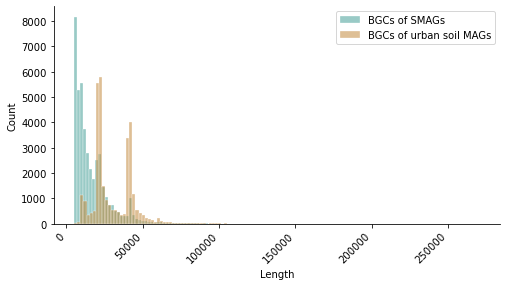

In [105]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=smag,
            x='Length',
            color='#35978f',binwidth=2000,alpha=0.5,label='BGCs of SMAGs',edgecolor='white')
sns.histplot(data=df,
            x='length',
            color='#bf812d',binwidth=2000,alpha=0.5,label='BGCs of urban soil MAGs',edgecolor='white')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.xticks(rotation=45, ha='right')
plt.legend(loc=1)

In [2]:
df = pd.read_csv(r'../pre-calculated_data/bgc_region_len_gtdb.tsv',sep='\t',header=None,names=['GBK','type','category','start','end','length','mag','gtdb','domain','phylum','class','order','family','genus','species'])
df

,GBK,type,category,start,end,length,mag,gtdb,domain,phylum,class,order,family,genus,species
0,snj13_SemiBin_61.fa_contig_6398_polypolish.reg...,RRE-containing,RiPP,16888,31236,14349,snj13_SemiBin_61,d__Bacteria;p__Pseudomonadota;c__Alphaproteoba...,d__Bacteria,p__Pseudomonadota,c__Alphaproteobacteria,o__Ferrovibrionales,f__Ferrovibrionaceae,g__Desertibaculum,s__
1,cpsnj02_SemiBin_18.fa_contig_6985_polypolish.r...,arylpolyene,other,1400180,1441370,41191,cpsnj02_SemiBin_18,d__Bacteria;p__Methylomirabilota;c__Methylomir...,d__Bacteria,p__Methylomirabilota,c__Methylomirabilia,o__Rokubacteriales,f__CSP1-6,g__DASXSB01,s__
2,snj08_SemiBin_1011.fa_contig_3158_polypolish.r...,terpene,terpene,52049,73981,21933,snj08_SemiBin_1011,d__Bacteria;p__Acidobacteriota;c__Blastocatell...,d__Bacteria,p__Acidobacteriota,c__Blastocatellia,o__RBC074,f__RBC074,g__JAHBSF01,s__
3,sample5_SemiBin_96.fa_contig_47116_polypolish....,RiPP-like,RiPP,16581,27843,11263,sample5_SemiBin_96,d__Bacteria;p__Nitrospirota;c__Nitrospiria;o__...,d__Bacteria,p__Nitrospirota,c__Nitrospiria,o__Nitrospirales,f__Nitrospiraceae,g__Nitrospira_C,s__Nitrospira_C sp029240595
4,sample27_SemiBin_67.fa_contig_139761_polypolis...,arylpolyene,other,82008,125596,43589,sample27_SemiBin_67,d__Bacteria;p__Pseudomonadota;c__Alphaproteoba...,d__Bacteria,p__Pseudomonadota,c__Alphaproteobacteria,o__Rhodospirillales,f__UXAT02,g__Defluviicoccus,s__
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31629,sample6_SemiBin_68.fa_contig_33264_polypolish....,RiPP-like,RiPP,16381,25059,8679,sample6_SemiBin_68,d__Bacteria;p__Myxococcota;c__Polyangia;o__Pol...,d__Bacteria,p__Myxococcota,c__Polyangia,o__Polyangiales,f__Polyangiaceae,g__PMG-095,s__
31630,sample8_SemiBin_8.fa_contig_283_polypolish.reg...,RRE-containing,RiPP,1,19240,19240,sample8_SemiBin_8,d__Bacteria;p__Acidobacteriota;c__Polarisedime...,d__Bacteria,p__Acidobacteriota,c__Polarisedimenticolia,o__Polarisedimenticolales,f__DASUFT01,g__,s__
31631,sample21_SemiBin_26.fa_contig_74783_polypolish...,terpene,terpene,42913,64637,21725,sample21_SemiBin_26,d__Bacteria;p__Methylomirabilota;c__Methylomir...,d__Bacteria,p__Methylomirabilota,c__Methylomirabilia,o__Rokubacteriales,f__CSP1-6,g__CAMLFJ01,s__
31632,sample20_SemiBin_1.fa_contig_5125_polypolish.r...,terpene,terpene,251483,273233,21751,sample20_SemiBin_1,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,d__Bacteria,p__Pseudomonadota,c__Gammaproteobacteria,o__Burkholderiales,f__Burkholderiaceae,g__JAOUJD01,s__


In [139]:
cluster = pd.read_csv(r'../pre-calculated_data/mix_clustering_c0.3.tsv',sep='\t')
cluster

,Record,GBK,Record_Type,Record_Number,CC,Family
0,cpsnj02_SemiBin_18.fa_contig_6985_polypolish.r...,cpsnj02_SemiBin_18.fa_contig_6985_polypolish.r...,region,3,5,FAM_00001
1,snj20_SemiBin_27.fa_contig_27097_polypolish.re...,snj20_SemiBin_27.fa_contig_27097_polypolish.re...,region,2,5,FAM_00001
2,snj15_SemiBin_80.fa_contig_81334_polypolish.re...,snj15_SemiBin_80.fa_contig_81334_polypolish.re...,region,1,5,FAM_00001
3,sample7_SemiBin_122.fa_contig_6681_polypolish....,sample7_SemiBin_122.fa_contig_6681_polypolish....,region,1,5,FAM_00001
4,snj09_SemiBin_99.fa_contig_12697_polypolish.re...,snj09_SemiBin_99.fa_contig_12697_polypolish.re...,region,4,5,FAM_00001
...,...,...,...,...,...,...
31629,sample7_SemiBin_145.fa_contig_75202_polypolish...,sample7_SemiBin_145.fa_contig_75202_polypolish...,region,1,147608,FAM_16297
31630,sample6_SemiBin_10.fa_contig_2173_polypolish.r...,sample6_SemiBin_10.fa_contig_2173_polypolish.r...,region,1,147628,FAM_16298
31631,snj13_SemiBin_95.fa_contig_23682_polypolish.re...,snj13_SemiBin_95.fa_contig_23682_polypolish.re...,region,1,147636,FAM_16299
31632,sample16_SemiBin_99.fa_contig_98589_polypolish...,sample16_SemiBin_99.fa_contig_98589_polypolish...,region,1,147640,FAM_16300


In [140]:
bgc_cluster = df.merge(cluster,on='GBK')
bgc_cluster

,GBK,type,category,start,end,length,mag,gtdb,domain,phylum,class,order,family,genus,species,Record,Record_Type,Record_Number,CC,Family
0,snj13_SemiBin_61.fa_contig_6398_polypolish.reg...,RRE-containing,RiPP,16888,31236,14349,snj13_SemiBin_61,d__Bacteria;p__Pseudomonadota;c__Alphaproteoba...,d__Bacteria,p__Pseudomonadota,c__Alphaproteobacteria,o__Ferrovibrionales,f__Ferrovibrionaceae,g__Desertibaculum,s__,snj13_SemiBin_61.fa_contig_6398_polypolish.reg...,region,1,1,FAM_03770
1,cpsnj02_SemiBin_18.fa_contig_6985_polypolish.r...,arylpolyene,other,1400180,1441370,41191,cpsnj02_SemiBin_18,d__Bacteria;p__Methylomirabilota;c__Methylomir...,d__Bacteria,p__Methylomirabilota,c__Methylomirabilia,o__Rokubacteriales,f__CSP1-6,g__DASXSB01,s__,cpsnj02_SemiBin_18.fa_contig_6985_polypolish.r...,region,3,5,FAM_00001
2,snj08_SemiBin_1011.fa_contig_3158_polypolish.r...,terpene,terpene,52049,73981,21933,snj08_SemiBin_1011,d__Bacteria;p__Acidobacteriota;c__Blastocatell...,d__Bacteria,p__Acidobacteriota,c__Blastocatellia,o__RBC074,f__RBC074,g__JAHBSF01,s__,snj08_SemiBin_1011.fa_contig_3158_polypolish.r...,region,1,9,FAM_03771
3,sample5_SemiBin_96.fa_contig_47116_polypolish....,RiPP-like,RiPP,16581,27843,11263,sample5_SemiBin_96,d__Bacteria;p__Nitrospirota;c__Nitrospiria;o__...,d__Bacteria,p__Nitrospirota,c__Nitrospiria,o__Nitrospirales,f__Nitrospiraceae,g__Nitrospira_C,s__Nitrospira_C sp029240595,sample5_SemiBin_96.fa_contig_47116_polypolish....,region,1,13,FAM_03772
4,sample27_SemiBin_67.fa_contig_139761_polypolis...,arylpolyene,other,82008,125596,43589,sample27_SemiBin_67,d__Bacteria;p__Pseudomonadota;c__Alphaproteoba...,d__Bacteria,p__Pseudomonadota,c__Alphaproteobacteria,o__Rhodospirillales,f__UXAT02,g__Defluviicoccus,s__,sample27_SemiBin_67.fa_contig_139761_polypolis...,region,2,17,FAM_03773
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31629,sample6_SemiBin_68.fa_contig_33264_polypolish....,RiPP-like,RiPP,16381,25059,8679,sample6_SemiBin_68,d__Bacteria;p__Myxococcota;c__Polyangia;o__Pol...,d__Bacteria,p__Myxococcota,c__Polyangia,o__Polyangiales,f__Polyangiaceae,g__PMG-095,s__,sample6_SemiBin_68.fa_contig_33264_polypolish....,region,1,147644,FAM_16301
31630,sample8_SemiBin_8.fa_contig_283_polypolish.reg...,RRE-containing,RiPP,1,19240,19240,sample8_SemiBin_8,d__Bacteria;p__Acidobacteriota;c__Polarisedime...,d__Bacteria,p__Acidobacteriota,c__Polarisedimenticolia,o__Polarisedimenticolales,f__DASUFT01,g__,s__,sample8_SemiBin_8.fa_contig_283_polypolish.reg...,region,1,14063,FAM_01644
31631,sample21_SemiBin_26.fa_contig_74783_polypolish...,terpene,terpene,42913,64637,21725,sample21_SemiBin_26,d__Bacteria;p__Methylomirabilota;c__Methylomir...,d__Bacteria,p__Methylomirabilota,c__Methylomirabilia,o__Rokubacteriales,f__CSP1-6,g__CAMLFJ01,s__,sample21_SemiBin_26.fa_contig_74783_polypolish...,region,1,5836,FAM_01007
31632,sample20_SemiBin_1.fa_contig_5125_polypolish.r...,terpene,terpene,251483,273233,21751,sample20_SemiBin_1,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,d__Bacteria,p__Pseudomonadota,c__Gammaproteobacteria,o__Burkholderiales,f__Burkholderiaceae,g__JAOUJD01,s__,sample20_SemiBin_1.fa_contig_5125_polypolish.r...,region,2,37,FAM_00021


In [141]:
bgc_cluster['category'] = bgc_cluster['category'].apply(lambda x: 'hybrid' if isinstance(x, str) and '.' in x else x)
bgc_cluster

,GBK,type,category,start,end,length,mag,gtdb,domain,phylum,class,order,family,genus,species,Record,Record_Type,Record_Number,CC,Family
0,snj13_SemiBin_61.fa_contig_6398_polypolish.reg...,RRE-containing,RiPP,16888,31236,14349,snj13_SemiBin_61,d__Bacteria;p__Pseudomonadota;c__Alphaproteoba...,d__Bacteria,p__Pseudomonadota,c__Alphaproteobacteria,o__Ferrovibrionales,f__Ferrovibrionaceae,g__Desertibaculum,s__,snj13_SemiBin_61.fa_contig_6398_polypolish.reg...,region,1,1,FAM_03770
1,cpsnj02_SemiBin_18.fa_contig_6985_polypolish.r...,arylpolyene,other,1400180,1441370,41191,cpsnj02_SemiBin_18,d__Bacteria;p__Methylomirabilota;c__Methylomir...,d__Bacteria,p__Methylomirabilota,c__Methylomirabilia,o__Rokubacteriales,f__CSP1-6,g__DASXSB01,s__,cpsnj02_SemiBin_18.fa_contig_6985_polypolish.r...,region,3,5,FAM_00001
2,snj08_SemiBin_1011.fa_contig_3158_polypolish.r...,terpene,terpene,52049,73981,21933,snj08_SemiBin_1011,d__Bacteria;p__Acidobacteriota;c__Blastocatell...,d__Bacteria,p__Acidobacteriota,c__Blastocatellia,o__RBC074,f__RBC074,g__JAHBSF01,s__,snj08_SemiBin_1011.fa_contig_3158_polypolish.r...,region,1,9,FAM_03771
3,sample5_SemiBin_96.fa_contig_47116_polypolish....,RiPP-like,RiPP,16581,27843,11263,sample5_SemiBin_96,d__Bacteria;p__Nitrospirota;c__Nitrospiria;o__...,d__Bacteria,p__Nitrospirota,c__Nitrospiria,o__Nitrospirales,f__Nitrospiraceae,g__Nitrospira_C,s__Nitrospira_C sp029240595,sample5_SemiBin_96.fa_contig_47116_polypolish....,region,1,13,FAM_03772
4,sample27_SemiBin_67.fa_contig_139761_polypolis...,arylpolyene,other,82008,125596,43589,sample27_SemiBin_67,d__Bacteria;p__Pseudomonadota;c__Alphaproteoba...,d__Bacteria,p__Pseudomonadota,c__Alphaproteobacteria,o__Rhodospirillales,f__UXAT02,g__Defluviicoccus,s__,sample27_SemiBin_67.fa_contig_139761_polypolis...,region,2,17,FAM_03773
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31629,sample6_SemiBin_68.fa_contig_33264_polypolish....,RiPP-like,RiPP,16381,25059,8679,sample6_SemiBin_68,d__Bacteria;p__Myxococcota;c__Polyangia;o__Pol...,d__Bacteria,p__Myxococcota,c__Polyangia,o__Polyangiales,f__Polyangiaceae,g__PMG-095,s__,sample6_SemiBin_68.fa_contig_33264_polypolish....,region,1,147644,FAM_16301
31630,sample8_SemiBin_8.fa_contig_283_polypolish.reg...,RRE-containing,RiPP,1,19240,19240,sample8_SemiBin_8,d__Bacteria;p__Acidobacteriota;c__Polarisedime...,d__Bacteria,p__Acidobacteriota,c__Polarisedimenticolia,o__Polarisedimenticolales,f__DASUFT01,g__,s__,sample8_SemiBin_8.fa_contig_283_polypolish.reg...,region,1,14063,FAM_01644
31631,sample21_SemiBin_26.fa_contig_74783_polypolish...,terpene,terpene,42913,64637,21725,sample21_SemiBin_26,d__Bacteria;p__Methylomirabilota;c__Methylomir...,d__Bacteria,p__Methylomirabilota,c__Methylomirabilia,o__Rokubacteriales,f__CSP1-6,g__CAMLFJ01,s__,sample21_SemiBin_26.fa_contig_74783_polypolish...,region,1,5836,FAM_01007
31632,sample20_SemiBin_1.fa_contig_5125_polypolish.r...,terpene,terpene,251483,273233,21751,sample20_SemiBin_1,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,d__Bacteria,p__Pseudomonadota,c__Gammaproteobacteria,o__Burkholderiales,f__Burkholderiaceae,g__JAOUJD01,s__,sample20_SemiBin_1.fa_contig_5125_polypolish.r...,region,2,37,FAM_00021


In [142]:
family_category_counts = bgc_cluster.groupby('Family')['category'].transform('nunique')
family_category_counts

0        1
1        1
2        1
3        1
4        1
        ..
31629    1
31630    1
31631    1
31632    1
31633    1
Name: category, Length: 31634, dtype: int64

In [143]:
bgc_cluster.loc[family_category_counts > 1, 'category'] = 'hybrid'
bgc_cluster

,GBK,type,category,start,end,length,mag,gtdb,domain,phylum,class,order,family,genus,species,Record,Record_Type,Record_Number,CC,Family
0,snj13_SemiBin_61.fa_contig_6398_polypolish.reg...,RRE-containing,RiPP,16888,31236,14349,snj13_SemiBin_61,d__Bacteria;p__Pseudomonadota;c__Alphaproteoba...,d__Bacteria,p__Pseudomonadota,c__Alphaproteobacteria,o__Ferrovibrionales,f__Ferrovibrionaceae,g__Desertibaculum,s__,snj13_SemiBin_61.fa_contig_6398_polypolish.reg...,region,1,1,FAM_03770
1,cpsnj02_SemiBin_18.fa_contig_6985_polypolish.r...,arylpolyene,other,1400180,1441370,41191,cpsnj02_SemiBin_18,d__Bacteria;p__Methylomirabilota;c__Methylomir...,d__Bacteria,p__Methylomirabilota,c__Methylomirabilia,o__Rokubacteriales,f__CSP1-6,g__DASXSB01,s__,cpsnj02_SemiBin_18.fa_contig_6985_polypolish.r...,region,3,5,FAM_00001
2,snj08_SemiBin_1011.fa_contig_3158_polypolish.r...,terpene,terpene,52049,73981,21933,snj08_SemiBin_1011,d__Bacteria;p__Acidobacteriota;c__Blastocatell...,d__Bacteria,p__Acidobacteriota,c__Blastocatellia,o__RBC074,f__RBC074,g__JAHBSF01,s__,snj08_SemiBin_1011.fa_contig_3158_polypolish.r...,region,1,9,FAM_03771
3,sample5_SemiBin_96.fa_contig_47116_polypolish....,RiPP-like,RiPP,16581,27843,11263,sample5_SemiBin_96,d__Bacteria;p__Nitrospirota;c__Nitrospiria;o__...,d__Bacteria,p__Nitrospirota,c__Nitrospiria,o__Nitrospirales,f__Nitrospiraceae,g__Nitrospira_C,s__Nitrospira_C sp029240595,sample5_SemiBin_96.fa_contig_47116_polypolish....,region,1,13,FAM_03772
4,sample27_SemiBin_67.fa_contig_139761_polypolis...,arylpolyene,other,82008,125596,43589,sample27_SemiBin_67,d__Bacteria;p__Pseudomonadota;c__Alphaproteoba...,d__Bacteria,p__Pseudomonadota,c__Alphaproteobacteria,o__Rhodospirillales,f__UXAT02,g__Defluviicoccus,s__,sample27_SemiBin_67.fa_contig_139761_polypolis...,region,2,17,FAM_03773
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31629,sample6_SemiBin_68.fa_contig_33264_polypolish....,RiPP-like,RiPP,16381,25059,8679,sample6_SemiBin_68,d__Bacteria;p__Myxococcota;c__Polyangia;o__Pol...,d__Bacteria,p__Myxococcota,c__Polyangia,o__Polyangiales,f__Polyangiaceae,g__PMG-095,s__,sample6_SemiBin_68.fa_contig_33264_polypolish....,region,1,147644,FAM_16301
31630,sample8_SemiBin_8.fa_contig_283_polypolish.reg...,RRE-containing,RiPP,1,19240,19240,sample8_SemiBin_8,d__Bacteria;p__Acidobacteriota;c__Polarisedime...,d__Bacteria,p__Acidobacteriota,c__Polarisedimenticolia,o__Polarisedimenticolales,f__DASUFT01,g__,s__,sample8_SemiBin_8.fa_contig_283_polypolish.reg...,region,1,14063,FAM_01644
31631,sample21_SemiBin_26.fa_contig_74783_polypolish...,terpene,terpene,42913,64637,21725,sample21_SemiBin_26,d__Bacteria;p__Methylomirabilota;c__Methylomir...,d__Bacteria,p__Methylomirabilota,c__Methylomirabilia,o__Rokubacteriales,f__CSP1-6,g__CAMLFJ01,s__,sample21_SemiBin_26.fa_contig_74783_polypolish...,region,1,5836,FAM_01007
31632,sample20_SemiBin_1.fa_contig_5125_polypolish.r...,terpene,terpene,251483,273233,21751,sample20_SemiBin_1,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,d__Bacteria,p__Pseudomonadota,c__Gammaproteobacteria,o__Burkholderiales,f__Burkholderiaceae,g__JAOUJD01,s__,sample20_SemiBin_1.fa_contig_5125_polypolish.r...,region,2,37,FAM_00021


In [144]:
family_phylum_counts = bgc_cluster.groupby(['Family', 'phylum']).size().reset_index(name='count')
top_phylum_per_family = family_phylum_counts.loc[
    family_phylum_counts.groupby('Family')['count'].idxmax()
]
phylum_map = dict(zip(top_phylum_per_family['Family'], top_phylum_per_family['phylum']))
bgc_cluster['phylum_unified'] = bgc_cluster['Family'].map(phylum_map)
bgc_cluster

,GBK,type,category,start,end,length,mag,gtdb,domain,phylum,...,order,family,genus,species,Record,Record_Type,Record_Number,CC,Family,phylum_unified
0,snj13_SemiBin_61.fa_contig_6398_polypolish.reg...,RRE-containing,RiPP,16888,31236,14349,snj13_SemiBin_61,d__Bacteria;p__Pseudomonadota;c__Alphaproteoba...,d__Bacteria,p__Pseudomonadota,...,o__Ferrovibrionales,f__Ferrovibrionaceae,g__Desertibaculum,s__,snj13_SemiBin_61.fa_contig_6398_polypolish.reg...,region,1,1,FAM_03770,p__Pseudomonadota
1,cpsnj02_SemiBin_18.fa_contig_6985_polypolish.r...,arylpolyene,other,1400180,1441370,41191,cpsnj02_SemiBin_18,d__Bacteria;p__Methylomirabilota;c__Methylomir...,d__Bacteria,p__Methylomirabilota,...,o__Rokubacteriales,f__CSP1-6,g__DASXSB01,s__,cpsnj02_SemiBin_18.fa_contig_6985_polypolish.r...,region,3,5,FAM_00001,p__Methylomirabilota
2,snj08_SemiBin_1011.fa_contig_3158_polypolish.r...,terpene,terpene,52049,73981,21933,snj08_SemiBin_1011,d__Bacteria;p__Acidobacteriota;c__Blastocatell...,d__Bacteria,p__Acidobacteriota,...,o__RBC074,f__RBC074,g__JAHBSF01,s__,snj08_SemiBin_1011.fa_contig_3158_polypolish.r...,region,1,9,FAM_03771,p__Acidobacteriota
3,sample5_SemiBin_96.fa_contig_47116_polypolish....,RiPP-like,RiPP,16581,27843,11263,sample5_SemiBin_96,d__Bacteria;p__Nitrospirota;c__Nitrospiria;o__...,d__Bacteria,p__Nitrospirota,...,o__Nitrospirales,f__Nitrospiraceae,g__Nitrospira_C,s__Nitrospira_C sp029240595,sample5_SemiBin_96.fa_contig_47116_polypolish....,region,1,13,FAM_03772,p__Nitrospirota
4,sample27_SemiBin_67.fa_contig_139761_polypolis...,arylpolyene,other,82008,125596,43589,sample27_SemiBin_67,d__Bacteria;p__Pseudomonadota;c__Alphaproteoba...,d__Bacteria,p__Pseudomonadota,...,o__Rhodospirillales,f__UXAT02,g__Defluviicoccus,s__,sample27_SemiBin_67.fa_contig_139761_polypolis...,region,2,17,FAM_03773,p__Pseudomonadota
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31629,sample6_SemiBin_68.fa_contig_33264_polypolish....,RiPP-like,RiPP,16381,25059,8679,sample6_SemiBin_68,d__Bacteria;p__Myxococcota;c__Polyangia;o__Pol...,d__Bacteria,p__Myxococcota,...,o__Polyangiales,f__Polyangiaceae,g__PMG-095,s__,sample6_SemiBin_68.fa_contig_33264_polypolish....,region,1,147644,FAM_16301,p__Myxococcota
31630,sample8_SemiBin_8.fa_contig_283_polypolish.reg...,RRE-containing,RiPP,1,19240,19240,sample8_SemiBin_8,d__Bacteria;p__Acidobacteriota;c__Polarisedime...,d__Bacteria,p__Acidobacteriota,...,o__Polarisedimenticolales,f__DASUFT01,g__,s__,sample8_SemiBin_8.fa_contig_283_polypolish.reg...,region,1,14063,FAM_01644,p__Acidobacteriota
31631,sample21_SemiBin_26.fa_contig_74783_polypolish...,terpene,terpene,42913,64637,21725,sample21_SemiBin_26,d__Bacteria;p__Methylomirabilota;c__Methylomir...,d__Bacteria,p__Methylomirabilota,...,o__Rokubacteriales,f__CSP1-6,g__CAMLFJ01,s__,sample21_SemiBin_26.fa_contig_74783_polypolish...,region,1,5836,FAM_01007,p__Methylomirabilota
31632,sample20_SemiBin_1.fa_contig_5125_polypolish.r...,terpene,terpene,251483,273233,21751,sample20_SemiBin_1,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,d__Bacteria,p__Pseudomonadota,...,o__Burkholderiales,f__Burkholderiaceae,g__JAOUJD01,s__,sample20_SemiBin_1.fa_contig_5125_polypolish.r...,region,2,37,FAM_00021,p__Pseudomonadota


In [145]:
phylum_family_counts = bgc_cluster.groupby('phylum_unified')['Family'].nunique().sort_values(ascending=False).reset_index().head(15).sort_values(by='Family',ascending=True).set_index('phylum_unified')
phylum_family_counts

,Family
phylum_unified,
p__Tectomicrobia,87
p__Nitrospirota,194
p__Myxococcota_A,220
p__Eisenbacteria,221
p__Chloroflexota,455
p__Bacteroidota,473
p__Verrucomicrobiota,515
p__Planctomycetota,672
p__Actinomycetota,716


(array([   0., 2000., 4000., 6000.]),
 [Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, '')])

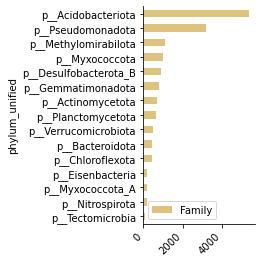

In [146]:
fig, ax = plt.subplots(figsize=(2, 4))
phylum_family_counts.plot(kind='barh', ax=ax,color='#dfc27d')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.xticks(rotation=45, ha='right')

In [147]:
gcf_unique_df = bgc_cluster[['Family', 'category', 'phylum_unified']].drop_duplicates()
gcf_unique_df

,Family,category,phylum_unified
0,FAM_03770,RiPP,p__Pseudomonadota
1,FAM_00001,other,p__Methylomirabilota
2,FAM_03771,terpene,p__Acidobacteriota
3,FAM_03772,RiPP,p__Nitrospirota
4,FAM_03773,other,p__Pseudomonadota
...,...,...,...
31622,FAM_16297,terpene,p__Acidobacteriota
31625,FAM_16298,NRPS,p__Actinomycetota
31627,FAM_16299,NRPS,p__Bacteroidota
31628,FAM_16300,PKS,p__Planctomycetota


In [148]:
counts = gcf_unique_df.groupby(['phylum_unified', 'category']).size().reset_index(name='count')
pivot_df = counts.pivot(index='phylum_unified', columns='category', values='count').fillna(0)
pivot_df

category,NRPS,PKS,RiPP,hybrid,other,saccharide,terpene
phylum_unified,,,,,,,
p__ARS69,1.0,10.0,3.0,0.0,0.0,0.0,7.0
p__Acidobacteriota,1335.0,472.0,1975.0,405.0,394.0,8.0,762.0
p__Actinomycetota,93.0,77.0,201.0,51.0,167.0,4.0,123.0
p__Armatimonadota,0.0,0.0,4.0,0.0,2.0,0.0,1.0
p__Bacteroidota,39.0,113.0,51.0,23.0,110.0,0.0,137.0
p__Bacteroidota_A,0.0,3.0,2.0,2.0,1.0,0.0,20.0
p__Bdellovibrionota,0.0,0.0,2.0,0.0,1.0,0.0,1.0
p__Bdellovibrionota_G,0.0,1.0,1.0,0.0,0.0,0.0,2.0
p__Chlamydiota,1.0,1.0,2.0,0.0,0.0,0.0,0.0


In [149]:
pivot_df['total'] = pivot_df.sum(axis=1)

pivot_top15 = pivot_df.sort_values('total', ascending=False).head(15)
pivot_top15

category,NRPS,PKS,RiPP,hybrid,other,saccharide,terpene,total
phylum_unified,,,,,,,,
p__Acidobacteriota,1335.0,472.0,1975.0,405.0,394.0,8.0,762.0,5351.0
p__Pseudomonadota,526.0,261.0,862.0,145.0,906.0,2.0,452.0,3154.0
p__Methylomirabilota,260.0,100.0,290.0,44.0,247.0,0.0,153.0,1094.0
p__Myxococcota,213.0,175.0,276.0,62.0,159.0,0.0,137.0,1022.0
p__Desulfobacterota_B,294.0,36.0,192.0,61.0,178.0,1.0,133.0,895.0
p__Gemmatimonadota,147.0,16.0,390.0,56.0,31.0,1.0,147.0,788.0
p__Actinomycetota,93.0,77.0,201.0,51.0,167.0,4.0,123.0,716.0
p__Planctomycetota,101.0,159.0,83.0,35.0,93.0,0.0,201.0,672.0
p__Verrucomicrobiota,85.0,45.0,28.0,20.0,88.0,0.0,249.0,515.0


In [150]:
pivot_top15 = pivot_top15.sort_values('total', ascending=True)

pivot_top15 = pivot_top15.drop(columns='total')

pivot_percent = pivot_top15.div(pivot_top15.sum(axis=1), axis=0)
pivot_percent

category,NRPS,PKS,RiPP,hybrid,other,saccharide,terpene
phylum_unified,,,,,,,
p__Tectomicrobia,0.252874,0.045977,0.287356,0.080460,0.218391,0.000000,0.114943
p__Nitrospirota,0.072165,0.005155,0.298969,0.046392,0.345361,0.000000,0.231959
p__Myxococcota_A,0.081818,0.154545,0.222727,0.059091,0.336364,0.000000,0.145455
p__Eisenbacteria,0.099548,0.271493,0.190045,0.018100,0.067873,0.000000,0.352941
p__Chloroflexota,0.158242,0.138462,0.136264,0.041758,0.175824,0.004396,0.345055
p__Bacteroidota,0.082452,0.238901,0.107822,0.048626,0.232558,0.000000,0.289641
p__Verrucomicrobiota,0.165049,0.087379,0.054369,0.038835,0.170874,0.000000,0.483495
p__Planctomycetota,0.150298,0.236607,0.123512,0.052083,0.138393,0.000000,0.299107
p__Actinomycetota,0.129888,0.107542,0.280726,0.071229,0.233240,0.005587,0.171788


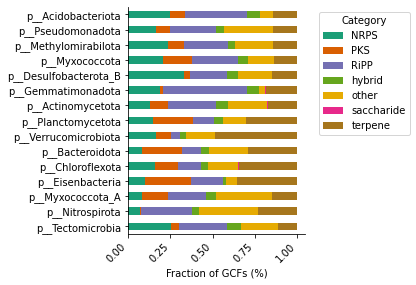

In [65]:
fig, ax = plt.subplots(figsize=(6, 4))
custom_colors = ['#1b9e77', '#d95f02', '#7570b3', '#66a61e', '#e6ab02', '#e7298a','#a6761d']
pivot_percent.plot(kind='barh', stacked=True,color=custom_colors,ax=ax)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.xlabel('Fraction of GCFs (%)')
plt.ylabel('')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

In [151]:
df = pd.read_csv(r'../pre-calculated_data/bgc_region_len_gtdb.tsv',sep='\t',header=None,names=['GBK','type','category','start','end','length','mag','gtdb','domain','phylum','class','order','family','genus','species'])
cluster = pd.read_csv(r'../pre-calculated_data/mix_clustering_c0.3.tsv',sep='\t')
bgc_cluster= df.merge(cluster,on='GBK')

In [152]:
aci = bgc_cluster[bgc_cluster['phylum']=='p__Acidobacteriota']
aci

,GBK,type,category,start,end,length,mag,gtdb,domain,phylum,class,order,family,genus,species,Record,Record_Type,Record_Number,CC,Family
2,snj08_SemiBin_1011.fa_contig_3158_polypolish.r...,terpene,terpene,52049,73981,21933,snj08_SemiBin_1011,d__Bacteria;p__Acidobacteriota;c__Blastocatell...,d__Bacteria,p__Acidobacteriota,c__Blastocatellia,o__RBC074,f__RBC074,g__JAHBSF01,s__,snj08_SemiBin_1011.fa_contig_3158_polypolish.r...,region,1,9,FAM_03771
5,cpsnj10_SemiBin_56.fa_contig_63352_polypolish....,NRPS-like.RRE-containing,NRPS.RiPP,40079,92751,52673,cpsnj10_SemiBin_56,d__Bacteria;p__Acidobacteriota;c__Vicinamibact...,d__Bacteria,p__Acidobacteriota,c__Vicinamibacteria,o__Vicinamibacterales,f__2-12-FULL-66-21,g__JACCXG01,s__,cpsnj10_SemiBin_56.fa_contig_63352_polypolish....,region,1,21,FAM_00002
8,sample21_SemiBin_1792.fa_contig_21797_polypoli...,PKS-like.hserlactone,PKS.other,116076,157377,41302,sample21_SemiBin_1792,d__Bacteria;p__Acidobacteriota;c__Vicinamibact...,d__Bacteria,p__Acidobacteriota,c__Vicinamibacteria,o__Vicinamibacterales,f__2-12-FULL-66-21,g__JACCXG01,s__,sample21_SemiBin_1792.fa_contig_21797_polypoli...,region,1,41,FAM_03775
18,sample26_SemiBin_4.fa_contig_10788_polypolish....,NRPS-like,NRPS,1351433,1393973,42541,sample26_SemiBin_4,d__Bacteria;p__Acidobacteriota;c__Vicinamibact...,d__Bacteria,p__Acidobacteriota,c__Vicinamibacteria,o__Vicinamibacterales,f__2-12-FULL-66-21,g__JACCXG01,s__,sample26_SemiBin_4.fa_contig_10788_polypolish....,region,2,94,FAM_00064
19,sample18_SemiBin_245.fa_contig_75220_polypolis...,terpene,terpene,68965,89672,20708,sample18_SemiBin_245,d__Bacteria;p__Acidobacteriota;c__Polarisedime...,d__Bacteria,p__Acidobacteriota,c__Polarisedimenticolia,o__Polarisedimenticolales,f__DASRJG01,g__DASRJG01,s__,sample18_SemiBin_245.fa_contig_75220_polypolis...,region,2,98,FAM_03780
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31618,sample1_SemiBin_188.fa_contig_180758_polypolis...,ranthipeptide,RiPP,21175,42623,21449,sample1_SemiBin_188,d__Bacteria;p__Acidobacteriota;c__Vicinamibact...,d__Bacteria,p__Acidobacteriota,c__Vicinamibacteria,o__Vicinamibacterales,f__SCN-69-37,g__,s__,sample1_SemiBin_188.fa_contig_180758_polypolis...,region,1,147592,FAM_16295
31619,sample4_SemiBin_24.fa_contig_15480_polypolish....,RiPP-like,RiPP,665861,677054,11194,sample4_SemiBin_24,d__Bacteria;p__Acidobacteriota;c__Blastocatell...,d__Bacteria,p__Acidobacteriota,c__Blastocatellia,o__Pyrinomonadales,f__Pyrinomonadaceae,g__PSRF01,s__,sample4_SemiBin_24.fa_contig_15480_polypolish....,region,2,2129,FAM_00535
31621,cpsnj19_SemiBin_167.fa_contig_38754_polypolish...,RRE-containing,RiPP,70191,90403,20213,cpsnj19_SemiBin_167,d__Bacteria;p__Acidobacteriota;c__Vicinamibact...,d__Bacteria,p__Acidobacteriota,c__Vicinamibacteria,o__Fen-336,f__Fen-336,g__JAICEW01,s__,cpsnj19_SemiBin_167.fa_contig_38754_polypolish...,region,1,147604,FAM_16296
31622,sample7_SemiBin_145.fa_contig_75202_polypolish...,terpene,terpene,1,10361,10361,sample7_SemiBin_145,d__Bacteria;p__Acidobacteriota;c__Vicinamibact...,d__Bacteria,p__Acidobacteriota,c__Vicinamibacteria,o__Vicinamibacterales,f__JACPPN01,g__,s__,sample7_SemiBin_145.fa_contig_75202_polypolish...,region,1,147608,FAM_16297


In [153]:
counts = aci[aci['genus'] != 'g__'].groupby(['genus', 'mag'])['Family'].nunique().reset_index()
counts 

,genus,mag,Family
0,g__12-FULL-67-14b,cpsnj02_SemiBin_81,5
1,g__12-FULL-67-14b,cpsnj03_SemiBin_10,2
2,g__12-FULL-67-14b,cpsnj03_SemiBin_110,3
3,g__12-FULL-67-14b,cpsnj03_SemiBin_78,3
4,g__12-FULL-67-14b,cpsnj04_SemiBin_112,4
...,...,...,...
1975,g__VFZN01,snj19_SemiBin_188,3
1976,g__VFZN01,snj20_SemiBin_183,2
1977,g__WHSN01,cpsnj09_SemiBin_45,1
1978,g__WHSN01,sample18_SemiBin_231,4


In [154]:
genus_avg = counts.groupby('genus')['Family'].mean().sort_values(ascending=False)
genus_avg

genus
g__UBA5704     18.571429
g__DATEKX01    11.000000
g__BOG-234     11.000000
g__DAISKN01     8.421053
g__JAHFTY01     8.000000
                 ...    
g__DASZRZ01     2.000000
g__DAHUXD01     1.772727
g__DATBFU01     1.000000
g__DATJFQ01     1.000000
g__JAENWF01     1.000000
Name: Family, Length: 125, dtype: float64

In [155]:
less_than_mean_count = (genus_avg < 4.22).sum()
total_genera = len(genus_avg)
percentage = (less_than_mean_count / total_genera) * 100
less_than_mean_count

69

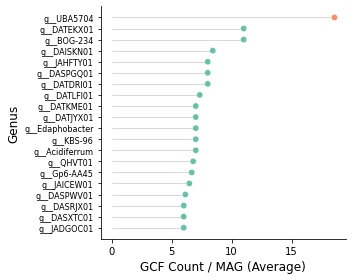

In [138]:
top_n = genus_avg.head(20).reset_index() 
top_n.columns = ['genus', 'avg_bgcs']

mean_val = 4.22

fig, ax = plt.subplots(figsize=(5, 4)) 

colors = ['#fc8d62' if x == 'g__UBA5704' else '#66c2a5' for x in top_n['genus']]

plt.hlines(y=top_n['genus'], xmin=0, xmax=top_n['avg_bgcs'], color='grey', alpha=0.3, linewidth=1)

plt.scatter(top_n['avg_bgcs'], top_n['genus'], color=colors, s=40, zorder=3, edgecolors='white', linewidths=0.5)

plt.xlabel('GCF Count / MAG (Average)', fontsize=12)
plt.ylabel('Genus', fontsize=12)

plt.yticks(fontsize=8) 
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.ylim(len(top_n), -1) 

plt.tight_layout()

In [156]:
UBA = bgc_cluster_o[bgc_cluster_o['genus']=='g__UBA5704']
UBA

,GBK,type,category,start,end,length,mag,gtdb,domain,phylum,class,order,family,genus,species,Record,Record_Type,Record_Number,CC,Family
113,snj02_SemiBin_33.fa_contig_1523_polypolish.reg...,NRPS.NRPS-like.T1PKS,NRPS.PKS,1,75458,75458,snj02_SemiBin_33,d__Bacteria;p__Acidobacteriota;c__Thermoanaero...,d__Bacteria,p__Acidobacteriota,c__Thermoanaerobaculia,o__Multivoradales,f__UBA5704,g__UBA5704,s__,snj02_SemiBin_33.fa_contig_1523_polypolish.reg...,region,1,522,FAM_03815
254,snj02_SemiBin_33.fa_contig_63015_polypolish.re...,RRE-containing,RiPP,156925,177191,20267,snj02_SemiBin_33,d__Bacteria;p__Acidobacteriota;c__Thermoanaero...,d__Bacteria,p__Acidobacteriota,c__Thermoanaerobaculia,o__Multivoradales,f__UBA5704,g__UBA5704,s__,snj02_SemiBin_33.fa_contig_63015_polypolish.re...,region,2,1262,FAM_03877
481,sample2_SemiBin_35.fa_contig_87020_polypolish....,RiPP-like,RiPP,21270,33447,12178,sample2_SemiBin_35,d__Bacteria;p__Acidobacteriota;c__Thermoanaero...,d__Bacteria,p__Acidobacteriota,c__Thermoanaerobaculia,o__Multivoradales,f__UBA5704,g__UBA5704,s__,sample2_SemiBin_35.fa_contig_87020_polypolish....,region,1,2293,FAM_03964
517,snj02_SemiBin_33.fa_contig_47980_polypolish.re...,NRPS.T1PKS,NRPS.PKS,76042,316787,240746,snj02_SemiBin_33,d__Bacteria;p__Acidobacteriota;c__Thermoanaero...,d__Bacteria,p__Acidobacteriota,c__Thermoanaerobaculia,o__Multivoradales,f__UBA5704,g__UBA5704,s__,snj02_SemiBin_33.fa_contig_47980_polypolish.re...,region,1,2445,FAM_03973
708,sample17_SemiBin_20.fa_contig_56357.region002,lanthipeptide-class-v.terpene,RiPP.terpene,184521,241397,56877,sample17_SemiBin_20,d__Bacteria;p__Acidobacteriota;c__Thermoanaero...,d__Bacteria,p__Acidobacteriota,c__Thermoanaerobaculia,o__Multivoradales,f__UBA5704,g__UBA5704,s__,sample17_SemiBin_20.fa_contig_56357.region002....,region,2,3411,FAM_00714
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30101,snj01_SemiBin_53.fa_contig_6850_polypolish.reg...,NRPS-like.lanthipeptide-class-iv,NRPS.RiPP,141215,184046,42832,snj01_SemiBin_53,d__Bacteria;p__Acidobacteriota;c__Thermoanaero...,d__Bacteria,p__Acidobacteriota,c__Thermoanaerobaculia,o__Multivoradales,f__UBA5704,g__UBA5704,s__,snj01_SemiBin_53.fa_contig_6850_polypolish.reg...,region,2,140496,FAM_15675
30306,snj08_SemiBin_95.fa_contig_78313_polypolish.re...,NRPS,NRPS,1,26632,26632,snj08_SemiBin_95,d__Bacteria;p__Acidobacteriota;c__Thermoanaero...,d__Bacteria,p__Acidobacteriota,c__Thermoanaerobaculia,o__Multivoradales,f__UBA5704,g__UBA5704,s__,snj08_SemiBin_95.fa_contig_78313_polypolish.re...,region,1,141457,FAM_15755
30852,snj08_SemiBin_95.fa_contig_23756_polypolish.re...,NRPS,NRPS,168482,204249,35768,snj08_SemiBin_95,d__Bacteria;p__Acidobacteriota;c__Thermoanaero...,d__Bacteria,p__Acidobacteriota,c__Thermoanaerobaculia,o__Multivoradales,f__UBA5704,g__UBA5704,s__,snj08_SemiBin_95.fa_contig_23756_polypolish.re...,region,1,143991,FAM_15983
31059,snj08_SemiBin_95.fa_contig_8269_polypolish.reg...,indole.ladderane,other,42247,96413,54167,snj08_SemiBin_95,d__Bacteria;p__Acidobacteriota;c__Thermoanaero...,d__Bacteria,p__Acidobacteriota,c__Thermoanaerobaculia,o__Multivoradales,f__UBA5704,g__UBA5704,s__,snj08_SemiBin_95.fa_contig_8269_polypolish.reg...,region,1,145033,FAM_16064


In [157]:
counts = UBA.groupby(['category'])['Family'].nunique().reset_index()
counts 

,category,Family
0,NRPS,39
1,NRPS.PKS,31
2,NRPS.PKS.RiPP,2
3,NRPS.PKS.other,1
4,NRPS.RiPP,3
5,NRPS.RiPP.terpene,1
6,PKS,11
7,RiPP,24
8,RiPP.terpene,3
9,other,11


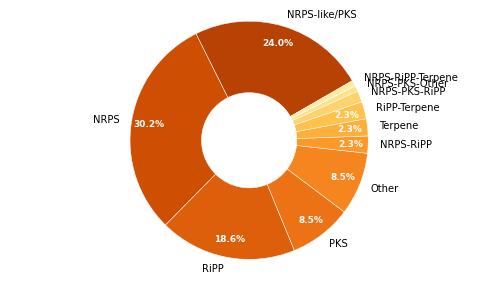

In [132]:
import matplotlib.pyplot as plt
import numpy as np

labels = ['NRPS/PKS','NRPS', 'RiPP', 'PKS', 'Other', 'NRPS/RiPP', 
          'Terpene', 'RiPP/Terpene', 'NRPS/PKS/RiPP', 'NRPS/PKS/Other', 'NRPS/RiPP/Terpene']
sizes = [31,39, 24, 11, 11, 3, 3, 3, 2, 1, 1]


cmap = plt.get_cmap("YlOrBr")
colors = cmap(np.linspace(0.8, 0.2, len(sizes)))

fig, ax = plt.subplots(figsize=(7, 4))

wedges, texts, autotexts = ax.pie(
    sizes, 
    labels=labels, 
    colors=colors, 
    autopct=lambda p: '{:.1f}%'.format(p) if p > 2 else '',
    startangle=30,
    pctdistance=0.85,    
    labeldistance=1.1,   
    wedgeprops={'width': 0.6, 'edgecolor': 'white', 'linewidth': 0.5}, 
    textprops={'fontsize': 10}
)

plt.setp(autotexts, size=9, weight="bold", color="white") 
plt.setp(texts, size=10) 

plt.axis('equal')  
plt.tight_layout()

In [158]:
counts = UBA.groupby(['mag'])['Family'].nunique().reset_index()
counts 

,mag,Family
0,sample17_SemiBin_20,13
1,sample18_SemiBin_189,7
2,sample2_SemiBin_35,12
3,snj01_SemiBin_53,38
4,snj02_SemiBin_33,26
5,snj08_SemiBin_95,21
6,snj09_SemiBin_114,13


In [159]:
counts = bgc_cluster.groupby(['phylum', 'mag'])['Family'].nunique().reset_index()
counts 

,phylum,mag,Family
0,p__ARS69,cpsnj11_SemiBin_122,2
1,p__ARS69,cpsnj14_SemiBin_7,3
2,p__ARS69,sample13_SemiBin_37,3
3,p__ARS69,sample13_SemiBin_38,3
4,p__ARS69,sample15_SemiBin_213,2
...,...,...,...
7453,p__Zhuqueibacterota,sample19_SemiBin_143,3
7454,p__Zhuqueibacterota,sample25_SemiBin_37,1
7455,p__Zhuqueibacterota,sample7_SemiBin_63,2
7456,p__Zixibacteria,sample19_SemiBin_217,1


In [160]:
phylum_avg = counts.groupby('phylum')['Family'].mean().sort_values(ascending=False)
top_phylum = phylum_avg.head(10).index.tolist()

top_data = counts[counts['phylum'].isin(top_phylum)]
top_data['phylum'] = pd.Categorical(top_data['phylum'], categories=top_phylum, ordered=True)
top_data

<ipython-input-160-48eff4936240>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_data['phylum'] = pd.Categorical(top_data['phylum'], categories=top_phylum, ordered=True)


,phylum,mag,Family
21,p__Acidobacteriota,cpsnj01_SemiBin_10,5
22,p__Acidobacteriota,cpsnj01_SemiBin_123,3
23,p__Acidobacteriota,cpsnj01_SemiBin_124,5
24,p__Acidobacteriota,cpsnj01_SemiBin_127,1
25,p__Acidobacteriota,cpsnj01_SemiBin_14,7
...,...,...,...
7447,p__Verrucomicrobiota,snj19_SemiBin_63,3
7448,p__Verrucomicrobiota,snj19_SemiBin_76,8
7449,p__Verrucomicrobiota,snj20_SemiBin_20,3
7450,p__Verrucomicrobiota,snj20_SemiBin_49,6


<ipython-input-97-b53fad41efef>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.boxplot(data=top_data, x="phylum", y="Family",palette="Blues",linewidth=1.5)


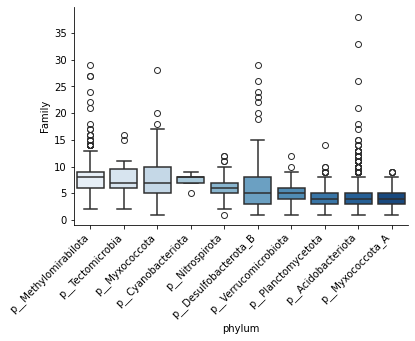

In [97]:
fig, ax = plt.subplots(figsize=(6, 4))
ax=sns.boxplot(data=top_data, x="phylum", y="Family",palette="Blues",linewidth=1.5)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.xticks(rotation=45, ha='right')

In [161]:
counts ['Family'].mean()

4.22177527487262

In [99]:
counts ['Family'].std()

2.976578900668701

In [107]:
phylum_gcf_summary = counts.groupby('phylum')['Family'].agg(['mean', 'std']).reset_index()
phylum_gcf_summary = phylum_gcf_summary.sort_values(by='mean', ascending=False)
phylum_gcf_summary

,phylum,mean,std
25,p__Methylomirabilota,8.199430,3.700208
34,p__Tectomicrobia,7.800000,3.876670
26,p__Myxococcota,7.664706,4.159461
10,p__Cyanobacteriota,7.400000,1.516575
28,p__Nitrospirota,6.141791,2.163098
13,p__Desulfobacterota_B,5.993127,4.151438
37,p__Verrucomicrobiota,4.894410,1.979907
31,p__Planctomycetota,4.310526,2.219060
1,p__Acidobacteriota,4.245947,2.487868
27,p__Myxococcota_A,4.111111,2.068732


In [108]:
counts = gcf_unique_df.groupby(['category']).size().reset_index(name='count').sort_values('count', ascending=False).head(10).set_index('category')
counts

,count
category,
RiPP,4760
NRPS,3287
terpene,2906
other,2673
PKS,1695
hybrid,962
saccharide,18


(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, 'RiPP'),
  Text(1, 0, 'NRPS'),
  Text(2, 0, 'terpene'),
  Text(3, 0, 'other'),
  Text(4, 0, 'PKS'),
  Text(5, 0, 'hybrid'),
  Text(6, 0, 'saccharide')])

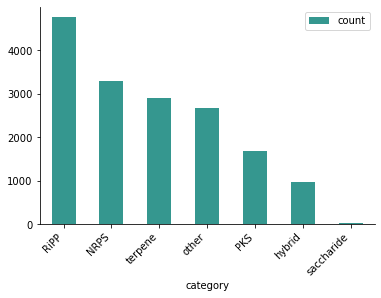

In [109]:
fig, ax = plt.subplots(figsize=(6, 4))
counts.plot(kind='bar', ax=ax,color='#35978f')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.xticks(rotation=45, ha='right')

In [111]:
gcf_unique_df

,Family,category,phylum_unified
0,FAM_03770,RiPP,p__Pseudomonadota
1,FAM_00001,other,p__Methylomirabilota
2,FAM_03771,terpene,p__Acidobacteriota
3,FAM_03772,RiPP,p__Nitrospirota
4,FAM_03773,other,p__Pseudomonadota
...,...,...,...
31622,FAM_16297,terpene,p__Acidobacteriota
31625,FAM_16298,NRPS,p__Actinomycetota
31627,FAM_16299,NRPS,p__Bacteroidota
31628,FAM_16300,PKS,p__Planctomycetota


In [113]:
counts = gcf_unique_df.groupby(['category','phylum_unified']).size().reset_index(name='count')
counts

,category,phylum_unified,count
0,NRPS,p__ARS69,1
1,NRPS,p__Acidobacteriota,1335
2,NRPS,p__Actinomycetota,93
3,NRPS,p__Bacteroidota,39
4,NRPS,p__Chlamydiota,1
...,...,...,...
175,terpene,p__Pseudomonadota,452
176,terpene,p__Tectomicrobia,10
177,terpene,p__UBA10199,10
178,terpene,p__Verrucomicrobiota,249


In [120]:
counts[counts['phylum_unified']=='p__Thermoproteota']

,category,phylum_unified,count
23,NRPS,p__Thermoproteota,1
55,PKS,p__Thermoproteota,1
90,RiPP,p__Thermoproteota,75


In [118]:
counts[counts['category']=='RiPP']

,category,phylum_unified,count
59,RiPP,p__ARS69,3
60,RiPP,p__Acidobacteriota,1975
61,RiPP,p__Actinomycetota,201
62,RiPP,p__Armatimonadota,4
63,RiPP,p__Bacteroidota,51
64,RiPP,p__Bacteroidota_A,2
65,RiPP,p__Bdellovibrionota,2
66,RiPP,p__Bdellovibrionota_G,1
67,RiPP,p__Chlamydiota,2
68,RiPP,p__Chloroflexota,62


In [121]:
counts[counts['category']=='NRPS']

,category,phylum_unified,count
0,NRPS,p__ARS69,1
1,NRPS,p__Acidobacteriota,1335
2,NRPS,p__Actinomycetota,93
3,NRPS,p__Bacteroidota,39
4,NRPS,p__Chlamydiota,1
5,NRPS,p__Chloroflexota,72
6,NRPS,p__Cyanobacteriota,4
7,NRPS,p__Desulfobacterota,4
8,NRPS,p__Desulfobacterota_B,294
9,NRPS,p__Desulfobacterota_D,4


In [123]:
counts[counts['category']=='terpene']

,category,phylum_unified,count
151,terpene,p__ARS69,7
152,terpene,p__Acidobacteriota,762
153,terpene,p__Actinomycetota,123
154,terpene,p__Armatimonadota,1
155,terpene,p__Bacteroidota,137
156,terpene,p__Bacteroidota_A,20
157,terpene,p__Bdellovibrionota,1
158,terpene,p__Bdellovibrionota_G,2
159,terpene,p__Chloroflexota,157
160,terpene,p__DASVDK01,1
